## Data Retrieval

In [2]:
import os
import glob
import pandas as pd

In [3]:
def _csv_instrument_key(path):
	basename = os.path.splitext(os.path.basename(path))[0]
	if "_" in basename:
		return basename.split("_", 1)[0]
	return basename


def load_csvs_from_folder(folder_path="data"):
	"""Recursively load all CSV files under `folder_path` into a dict of DataFrames.

	Keys are the instrument names derived from the CSV filenames.
	For example, `CRUDEOILM_historical_data.csv` becomes `CRUDEOILM`.

	Returns:
		dict: {instrument_name: pandas.DataFrame}
	"""
	folder = os.path.abspath(folder_path)
	if not os.path.isdir(folder):
		raise FileNotFoundError(f"Folder not found: {folder}")

	# Find CSVs recursively
	csv_paths = sorted(glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True))
	dataframes = {}
	for path in csv_paths:
		key = _csv_instrument_key(path)
		try:
			# Detect if a 'date' column exists (case-insensitive) and parse it
			header_cols = pd.read_csv(path, nrows=0).columns.tolist()
			lower_cols = [c.lower() for c in header_cols]
			parse_dates = [header_cols[i] for i, c in enumerate(lower_cols) if c == 'date'] or None
			if parse_dates:
				df = pd.read_csv(path, parse_dates=parse_dates)
			else:
				df = pd.read_csv(path)
			dataframes[key] = df
		except Exception as e:
			print(f"Failed to load {path}: {e}")
	return dataframes


def load_req_csvs(folder_path="data", instruments=None):
	"""Load only CSVs whose file name matches one of the provided instruments.

	Args:
		folder_path (str): root folder to search (recursively).
		instruments (list[str]): list of instrument names to filter by. Matching is
			case-insensitive and checks if an instrument string appears anywhere in
			the CSV filename, such as `CRUDEOILM_historical_data.csv`.

	Returns:
		dict: {instrument_name: pandas.DataFrame} for matching files.
	"""
	if not instruments:
		raise ValueError("`instruments` must be a non-empty list of instrument names")

	# normalize instruments for case-insensitive matching
	inst_upper = [str(i).upper() for i in instruments]

	folder = os.path.abspath(folder_path)
	if not os.path.isdir(folder):
		raise FileNotFoundError(f"Folder not found: {folder}")

	csv_paths = sorted(glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True))
	dataframes = {}
	for path in csv_paths:
		key = _csv_instrument_key(path)
		key_upper = key.upper()

		# include file if any instrument name is found in the CSV filename
		if not any(inst in key_upper for inst in inst_upper):
			continue

		try:
			header_cols = pd.read_csv(path, nrows=0).columns.tolist()
			lower_cols = [c.lower() for c in header_cols]
			parse_dates = [header_cols[i] for i, c in enumerate(lower_cols) if c == 'date'] or None
			if parse_dates:
				df = pd.read_csv(path, parse_dates=parse_dates)
			else:
				df = pd.read_csv(path)
			dataframes[key] = df
		except Exception as e:
			print(f"Failed to load {path}: {e}")

	return dataframes


def filter_close_price(df):
	"""Filter the DataFrame to include only 'date' and 'close' columns, if they exist."""
	cols = df.columns.str.lower()
	date_col = df.columns[cols == 'date'][0] if 'date' in cols else None
	close_col = df.columns[cols == 'close'][0] if 'close' in cols else None

	if date_col and close_col:
		return df[[date_col, close_col]].rename(columns={date_col: 'date', close_col: 'close'})
	else:
		print("Warning: 'date' or 'close' column not found. Returning original DataFrame.")
		return df

In [4]:
dfs = load_req_csvs("data", instruments=['NIFTY', 'BANKNIFTY', 'CRUDEOILM', 'GOLDGUINEA', 'NATGASMINI', 'SILVERMIC', 'USDINR', 'EURINR'])
print(f"Loaded {len(dfs)} CSVs: {list(dfs.keys())}")


for key in dfs:
    dfs[key] = filter_close_price(dfs[key])

dfs['NIFTY'].head()

Loaded 11 CSVs: ['EURINR', 'USDINR', 'CRUDEOILM', 'GOLDGUINEA', 'NATGASMINI', 'SILVERMIC', 'BANKNIFTY', 'FINNIFTY', 'MIDCPNIFTY', 'NIFTYNXT50', 'NIFTY']


,date,close
0,2021-05-28 00:00:00+05:30,15463.85
1,2021-05-31 00:00:00+05:30,15583.20
2,2021-06-01 00:00:00+05:30,15618.15
3,2021-06-02 00:00:00+05:30,15616.75
4,2021-06-03 00:00:00+05:30,15712.40


## Backadjustment

In [5]:
import calendar

Below function backadjusts data keeping rollover as a fixed date (Eg: 17th of every month). This is useful for MCX market contracts

In [6]:
def backadjust_expiry_date(df, rollover_day, date_col="date", price_col="close", adj_col="close_adj"):
    """
    Add additive back-adjustment on the given rollover day.
    If the rollover day is a holiday, the previous available trading date is used.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.tz_localize(None).dt.normalize()
    df = df.sort_values(date_col).reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    if df.empty:
        return df

    available_dates = set(df[date_col])
    df["adj_offset"] = 0.0

    months = sorted({(d.year, d.month) for d in df[date_col]})
    for year, month in months:
        target_day = min(rollover_day, calendar.monthrange(year, month)[1])
        target = pd.Timestamp(year, month, target_day)

        if target > df[date_col].max():
            continue

        if target in available_dates:
            rollover_date = target
        else:
            prior = df[df[date_col] < target]
            if prior.empty:
                continue
            rollover_date = prior[date_col].max()

        idx = df.index[df[date_col] == rollover_date]
        if len(idx) == 0:
            continue
        idx = idx[0]
        if idx == 0:
            continue

        gap = df.at[idx, price_col] - df.at[idx - 1, price_col]
        df.loc[: idx - 1, "adj_offset"] += gap

    df[adj_col] = df[price_col] - df["adj_offset"]
    return df.drop(columns=["adj_offset"])

This function backadjusts data keeping the last given weekday as the expiry day (Eg: Last thursday of every month). This is useful for NFO contracts.

In [7]:
def _normalize_datetime_series(series):
    dt = pd.to_datetime(series, errors="coerce")
    if getattr(dt.dt, "tz", None) is not None:
        try:
            dt = dt.dt.tz_convert(None)
        except TypeError:
            dt = dt.dt.tz_localize(None)
    return dt.dt.tz_localize(None).dt.normalize()



In [13]:
def _parse_expiry_day(expiry_day):
    """Parse expiry day string like 'last thursday' and return (nth, weekday_idx).
    
    Args:
        expiry_day (str): e.g., 'last thursday', '1st monday', '3rd friday'
    
    Returns:
        tuple: (nth, weekday_idx) where nth is -1 for 'last', 1+ for ordinal, 
               and weekday_idx is 0-6 (Monday-Sunday)
    """
    parts = expiry_day.lower().strip().split()
    
    # Determine the nth value
    if parts[0] == 'last':
        nth = -1
    elif parts[0] in ['1st', '2nd', '3rd', '4th', '5th']:
        nth_map = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4, '5th': 5}
        nth = nth_map.get(parts[0], 1)
    else:
        raise ValueError(f"Invalid expiry day format: {expiry_day}")
    
    # Determine the weekday index (Monday=0, ..., Sunday=6)
    weekday_str = parts[-1].lower()
    weekday_map = {
        'monday': 0, 'tuesday': 1, 'wednesday': 2, 'thursday': 3,
        'friday': 4, 'saturday': 5, 'sunday': 6
    }
    
    weekday_idx = weekday_map.get(weekday_str)
    if weekday_idx is None:
        raise ValueError(f"Invalid weekday in expiry day: {weekday_str}")
    
    return nth, weekday_idx


def _month_expiry_date(year, month, weekday_idx, nth):
    """Return the date of the nth occurrence of a weekday in a given month.
    
    Args:
        year: year
        month: month (1-12)
        weekday_idx: weekday index (0=Monday, ..., 6=Sunday)
        nth: positive for "1st, 2nd, ..." or -1 for "last"
    
    Returns:
        datetime.date: The expiry date
    """
    import datetime
    
    if nth > 0:
        # Find the nth occurrence from the start
        first_day = datetime.date(year, month, 1)
        days_ahead = (weekday_idx - first_day.weekday()) % 7
        date = first_day + datetime.timedelta(days=days_ahead + (nth - 1) * 7)
        return date
    else:  # nth < 0 (e.g., -1 for "last")
        # Find from the end of the month
        last_day = calendar.monthrange(year, month)[1]
        last_date = datetime.date(year, month, last_day)
        days_back = (last_date.weekday() - weekday_idx) % 7
        date = last_date - datetime.timedelta(days=days_back)
        # Go back further for -2, -3, etc.
        for _ in range(-nth - 1):
            date -= datetime.timedelta(days=7)
        return date


In [8]:
def backadjust_expiry_fixed_day(df, expiry_day, date_col="date", price_col="close", adj_col="close_adj"):
    """Additive back-adjustment using a monthly expiry rule like 'last thursday'."""
    df = df.copy()
    df[date_col] = _normalize_datetime_series(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    if df.empty:
        return df

    nth, weekday_idx = _parse_expiry_day(expiry_day)
    available_dates = set(df[date_col])
    df["adj_offset"] = 0.0

    months = sorted({(d.year, d.month) for d in df[date_col]})
    for year, month in months:
        expiry_date = _month_expiry_date(year, month, weekday_idx, nth)
        expiry_date = pd.Timestamp(expiry_date)
        if expiry_date.tzinfo is not None:
            expiry_date = expiry_date.tz_convert(None)
        expiry_date = expiry_date.normalize()
        if expiry_date > df[date_col].max():
            continue

        if expiry_date in available_dates:
            rollover_date = expiry_date
        else:
            prior = df[df[date_col] < expiry_date]
            if prior.empty:
                continue
            rollover_date = prior[date_col].max()

        idx = df.index[df[date_col] == rollover_date]
        if len(idx) == 0 or idx[0] == 0:
            continue

        idx = idx[0]
        gap = df.at[idx, price_col] - df.at[idx - 1, price_col]
        df.loc[: idx - 1, "adj_offset"] += gap

    df[adj_col] = df[price_col] - df["adj_offset"]
    return df.drop(columns=["adj_offset"])


This function keeps the expiry day as two days before the last trading day of every month. This is useful for CDS contracts.

In [19]:
def backadjust_n_days_before_last(df, n_days_before_last=2, date_col="date", price_col="close", adj_col="close_adj"):
    """Additive back-adjustment using the n-th trading day before the last trading day of each month.

    Args:
        df: input DataFrame containing date and price columns.
        n_days_before_last: 0 means last trading day, 1 means second-to-last, 2 means third-to-last, etc.
        date_col: name of the date column.
        price_col: name of the price column.
        adj_col: output adjusted price column.
    """
    if n_days_before_last < 0:
        raise ValueError("n_days_before_last must be >= 0")

    df = df.copy()
    df[date_col] = _normalize_datetime_series(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    if df.empty:
        return df

    df["adj_offset"] = 0.0
    grouped = df.groupby([df[date_col].dt.year, df[date_col].dt.month])

    for (year, month), group in grouped:
        if len(group) <= n_days_before_last:
            continue

        target_date = group[date_col].nlargest(n_days_before_last + 1).iloc[-1]
        idx = df.index[df[date_col] == target_date]
        if len(idx) == 0 or idx[0] == 0:
            continue

        idx = idx[0]
        gap = df.at[idx, price_col] - df.at[idx - 1, price_col]
        df.loc[: idx - 1, "adj_offset"] += gap

    df[adj_col] = df[price_col] - df["adj_offset"]
    return df.drop(columns=["adj_offset"])


In [17]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'NIFTY Back-Adjusted Close Price'}, xlabel='date'>

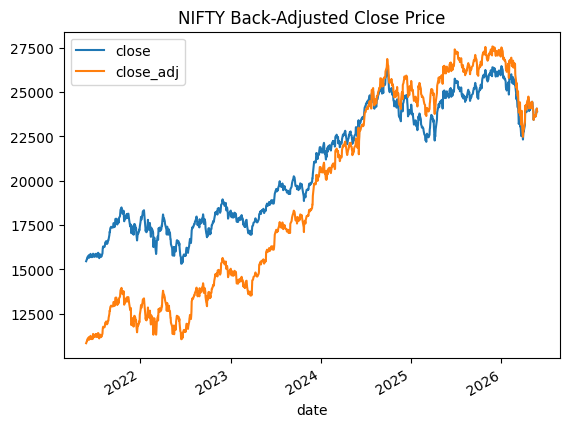

In [15]:
nifty_backadj = backadjust_expiry_fixed_day(dfs['NIFTY'], expiry_day="last thursday")

nifty_backadj.plot(x="date", y=["close", "close_adj"], title="NIFTY Back-Adjusted Close Price")

<Axes: title={'center': 'CRUDEOILM Back-Adjusted Close Price'}, xlabel='date'>

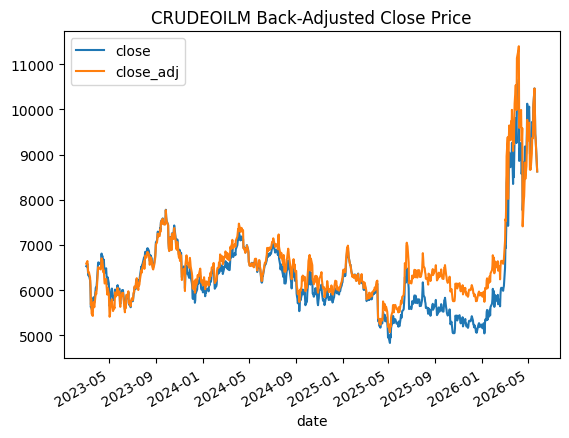

In [21]:
crudeoil_backadj = backadjust_expiry_date(dfs['CRUDEOILM'], rollover_day=17)

crudeoil_backadj.plot(x="date", y=["close", "close_adj"], title="CRUDEOILM Back-Adjusted Close Price")

<Axes: title={'center': 'USDINR Back-Adjusted Close Price'}, xlabel='date'>

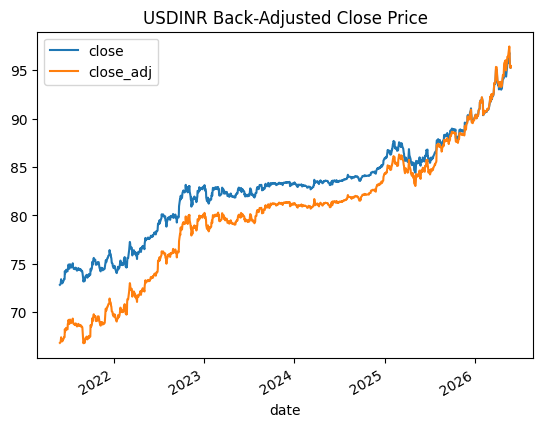

In [22]:
usdinr_backadj = backadjust_n_days_before_last(dfs['USDINR'], n_days_before_last=2)

usdinr_backadj.plot(x="date", y=["close", "close_adj"], title="USDINR Back-Adjusted Close Price")

## Calculating Returns

In [24]:
instruments = load_csvs_from_folder("data/backadjusted/")

print(instruments.keys())

dict_keys(['crudeoilm', 'goldguinea', 'natgasmini', 'nifty', 'silvermic', 'usdinr'])


In [26]:
def calculate_returns(df, price_col='close_adj', return_col='returns', date_col='date', inplace=True, fill_na_value=None):
    """Calculate daily returns from a price column and add a `returns` column.

    Args:
        df (pd.DataFrame): input DataFrame.
        price_col (str): column with adjusted close prices. Default 'close_adj'.
        return_col (str): name of the returns column to add. Default 'returns'.
        date_col (str|None): optional date column to sort by before computing returns.
        inplace (bool): if True, modify the passed DataFrame and return it; if False, return a new DataFrame.
        fill_na_value (float|None): if not None, fill the NaN in the first return with this value.

    Returns:
        pd.DataFrame: DataFrame with the new returns column (same object if inplace=True).
    """
    if not inplace:
        df = df.copy()

    if date_col and date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df.sort_values(date_col, inplace=True)

    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

    returns = df[price_col].pct_change()
    if fill_na_value is not None:
        returns = returns.fillna(fill_na_value)

    df[return_col] = returns
    return df


### Instrument Stats

In [47]:
def calculate_return_stats(prices, price_col='close_adj', date_col='date', trading_days=256, rf=0.0, return_col='returns', plot=True, figsize=(14, 12)):
    """Compute return statistics and show distribution, cumulative returns, and drawdown charts.

    Args:
        prices (pd.DataFrame or pd.Series): adjusted prices or DataFrame containing adjusted prices.
        price_col (str): column name for adjusted close prices when prices is a DataFrame.
        date_col (str): optional date column used to sort the DataFrame.
        trading_days (int): number of trading days per year for annualization.
        rf (float): annual risk-free rate.
        return_col (str): column name to add to the DataFrame when input is a DataFrame.
        plot (bool): whether to draw distribution, cumulative returns and drawdown charts.
        figsize (tuple): matplotlib figure size.

    Returns:
        dict: a dictionary containing metrics, explanations, and computed series.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if isinstance(prices, pd.DataFrame):
        df = prices.copy()
        if date_col and date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
            df = df.sort_values(date_col).reset_index(drop=True)
        price_series = pd.to_numeric(df[price_col], errors='coerce')
        returns = price_series.pct_change()
        df[return_col] = returns
    elif isinstance(prices, pd.Series):
        price_series = prices.astype(float)
        returns = price_series.pct_change()
        df = None
    else:
        raise TypeError('prices must be a pandas DataFrame or Series')

    returns = returns.dropna()
    n_obs = returns.shape[0]

    metrics = {
        'annual_return': np.nan,
        'annual_volatility': np.nan,
        'sharpe_ratio': np.nan,
        'max_drawdown': np.nan,
        'drawdown_duration': 0,
        'skewness': np.nan,
        'left_tail_mean_5pct': np.nan,
        'right_tail_mean_5pct': np.nan,
        'left_tail_threshold_5pct': np.nan,
        'right_tail_threshold_5pct': np.nan,
        'left_tail_pct': np.nan,
        'right_tail_pct': np.nan,
        'total_observations': n_obs,
    }

    explanations = {
        'annual_return': 'Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.',
        'annual_volatility': 'Annualized standard deviation of daily returns using 256 trading days.',
        'sharpe_ratio': 'Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.',
        'max_drawdown': 'Largest peak-to-trough decline in cumulative returns during the sample period.',
        'drawdown_duration': 'Maximum number of consecutive days spent below the previous peak.',
        'skewness': 'Measure of asymmetry in the daily return distribution.',
        'left_tail_mean_5pct': 'Average return in the worst 5% of daily observations.',
        'right_tail_mean_5pct': 'Average return in the best 5% of daily observations.',
        'left_tail_threshold_5pct': 'The 5th percentile return, used to define the left tail.',
        'right_tail_threshold_5pct': 'The 95th percentile return, used to define the right tail.',
    }

    if n_obs > 0:
        cumulative_returns = (1 + returns).cumprod()
        total_return = cumulative_returns.iloc[-1] - 1
        years = n_obs / trading_days
        if years > 0 and total_return > -1:
            metrics['annual_return'] = ((1 + total_return) ** (1 / years) - 1) * 100

        daily_vol = returns.std(ddof=1)
        metrics['annual_volatility'] = daily_vol * np.sqrt(trading_days) * 100

        excess_daily = returns - rf / trading_days
        if daily_vol != 0 and not np.isnan(daily_vol):
            metrics['sharpe_ratio'] = excess_daily.mean() / daily_vol * np.sqrt(trading_days) * 100

        running_max = cumulative_returns.cummax()
        drawdown = cumulative_returns / running_max - 1
        metrics['max_drawdown'] = float(drawdown.min()) * 100

        duration = 0
        max_duration = 0
        for dd in drawdown:
            if dd < 0:
                duration += 1
            else:
                if duration > max_duration:
                    max_duration = duration
                duration = 0
        max_duration = max(max_duration, duration)
        metrics['drawdown_duration'] = int(max_duration)

        metrics['skewness'] = float(returns.skew())

        left_threshold = returns.quantile(0.05)
        right_threshold = returns.quantile(0.95)
        left_tail = returns[returns <= left_threshold]
        right_tail = returns[returns >= right_threshold]

        metrics['left_tail_mean_5pct'] = float(left_tail.mean()) * 100 if not left_tail.empty else np.nan
        metrics['right_tail_mean_5pct'] = float(right_tail.mean()) * 100 if not right_tail.empty else np.nan
        metrics['left_tail_threshold_5pct'] = float(left_threshold) * 100
        metrics['right_tail_threshold_5pct'] = float(right_threshold) * 100
        metrics['left_tail_pct'] = float((returns <= left_threshold).mean() * 100)
        metrics['right_tail_pct'] = float((returns >= right_threshold).mean() * 100)

        if plot:
            returns_pct = returns * 100
            fig, axes = plt.subplots(3, 1, figsize=figsize)

            axes[0].hist(returns_pct, bins=50, density=True, alpha=0.75, color='#4c72b0', edgecolor='black')
            axes[0].set_title('Daily Returns Distribution')
            axes[0].set_xlabel('Daily return (%)')
            axes[0].set_ylabel('Density')
            axes[0].axvline(returns_pct.mean(), color='red', linestyle='--', label=f'mean={returns_pct.mean():.2f}%')
            axes[0].legend()

            axes[1].plot(cumulative_returns.index, cumulative_returns, color='#2ca02c')
            axes[1].set_title('Cumulative Returns')
            axes[1].set_xlabel('Observation')
            axes[1].set_ylabel('Cumulative return')
            axes[1].grid(True, alpha=0.3)

            axes[2].fill_between(drawdown.index, drawdown, 0, step='mid', color='#d62728', alpha=0.5)
            axes[2].plot(drawdown.index, drawdown, color='#d62728')
            axes[2].set_title('Drawdown Chart')
            axes[2].set_xlabel('Observation')
            axes[2].set_ylabel('Drawdown')
            axes[2].grid(True, alpha=0.3)

            fig.tight_layout()
            plt.show()
    else:
        cumulative_returns = pd.Series(dtype=float)
        drawdown = pd.Series(dtype=float)

    return {
        'metrics': metrics,
        'explanations': explanations,
        'returns': returns,
        'cumulative_returns': cumulative_returns,
        'drawdown': drawdown,
        'dataframe': df,
    }


Calculating return stats for crudeoilm...


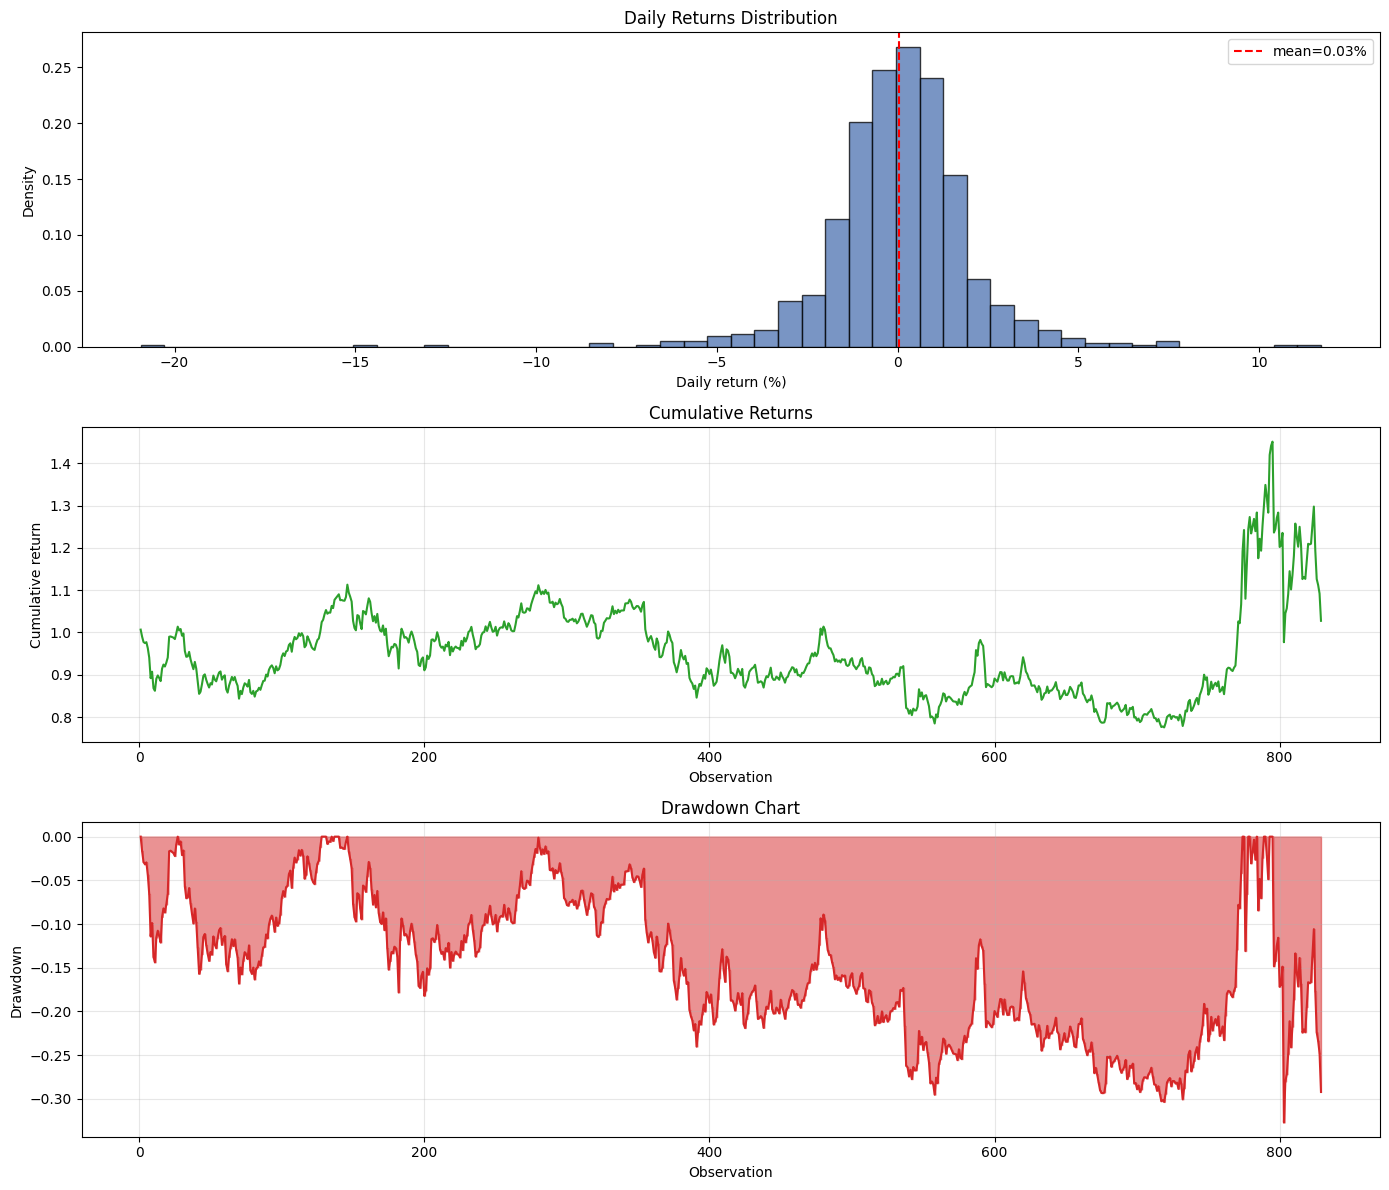

Metrics for crudeoilm:
  annual_return: 0.8454 - Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.
  annual_volatility: 34.4688 - Annualized standard deviation of daily returns using 256 trading days.
  sharpe_ratio: 20.1077 - Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.
  max_drawdown: -32.6988 - Largest peak-to-trough decline in cumulative returns during the sample period.
  drawdown_duration: 627.0000 - Maximum number of consecutive days spent below the previous peak.
  skewness: -1.4938 - Measure of asymmetry in the daily return distribution.
  left_tail_mean_5pct: -5.2797 - Average return in the worst 5% of daily observations.
  right_tail_mean_5pct: 4.6621 - Average return in the best 5% of daily observations.
  left_tail_threshold_5pct: -3.0586 - The 5th percentile return, used to define the left tail.
  right_tail_threshold_5pct: 3.0218 - The 95th percentile return, used to defi

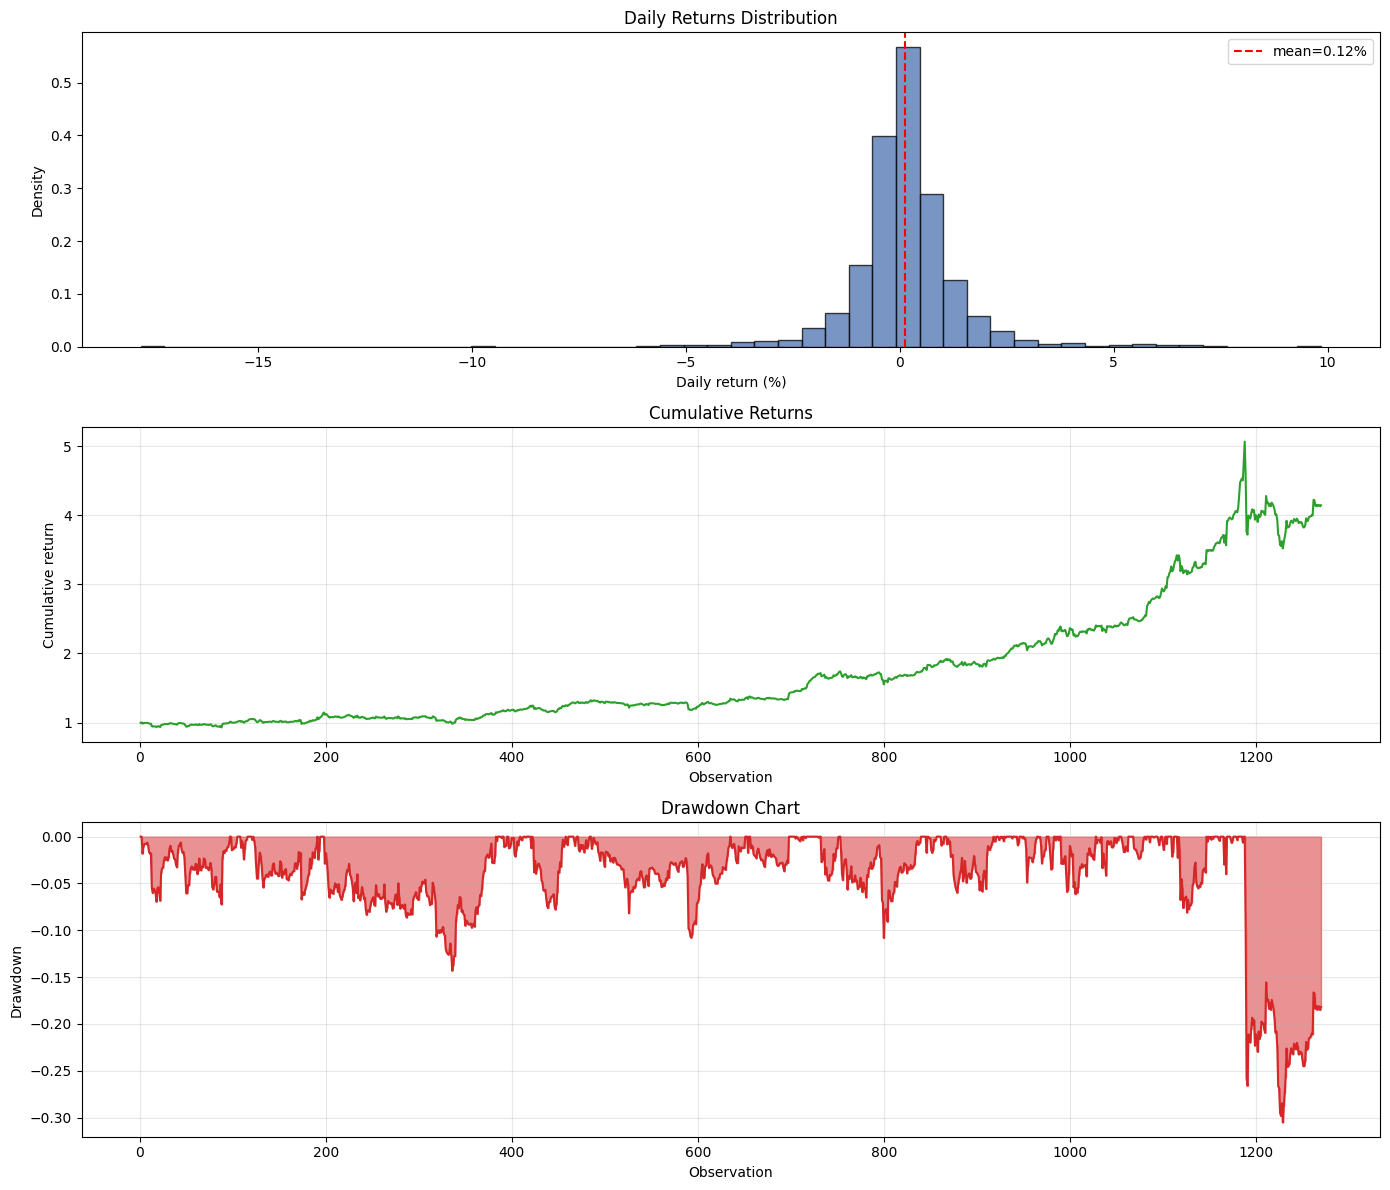

Metrics for goldguinea:
  annual_return: 33.1908 - Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.
  annual_volatility: 21.5194 - Annualized standard deviation of daily returns using 256 trading days.
  sharpe_ratio: 144.1767 - Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.
  max_drawdown: -30.5068 - Largest peak-to-trough decline in cumulative returns during the sample period.
  drawdown_duration: 184.0000 - Maximum number of consecutive days spent below the previous peak.
  skewness: -1.4400 - Measure of asymmetry in the daily return distribution.
  left_tail_mean_5pct: -2.9878 - Average return in the worst 5% of daily observations.
  right_tail_mean_5pct: 3.2863 - Average return in the best 5% of daily observations.
  left_tail_threshold_5pct: -1.5716 - The 5th percentile return, used to define the left tail.
  right_tail_threshold_5pct: 1.8433 - The 95th percentile return, used to d

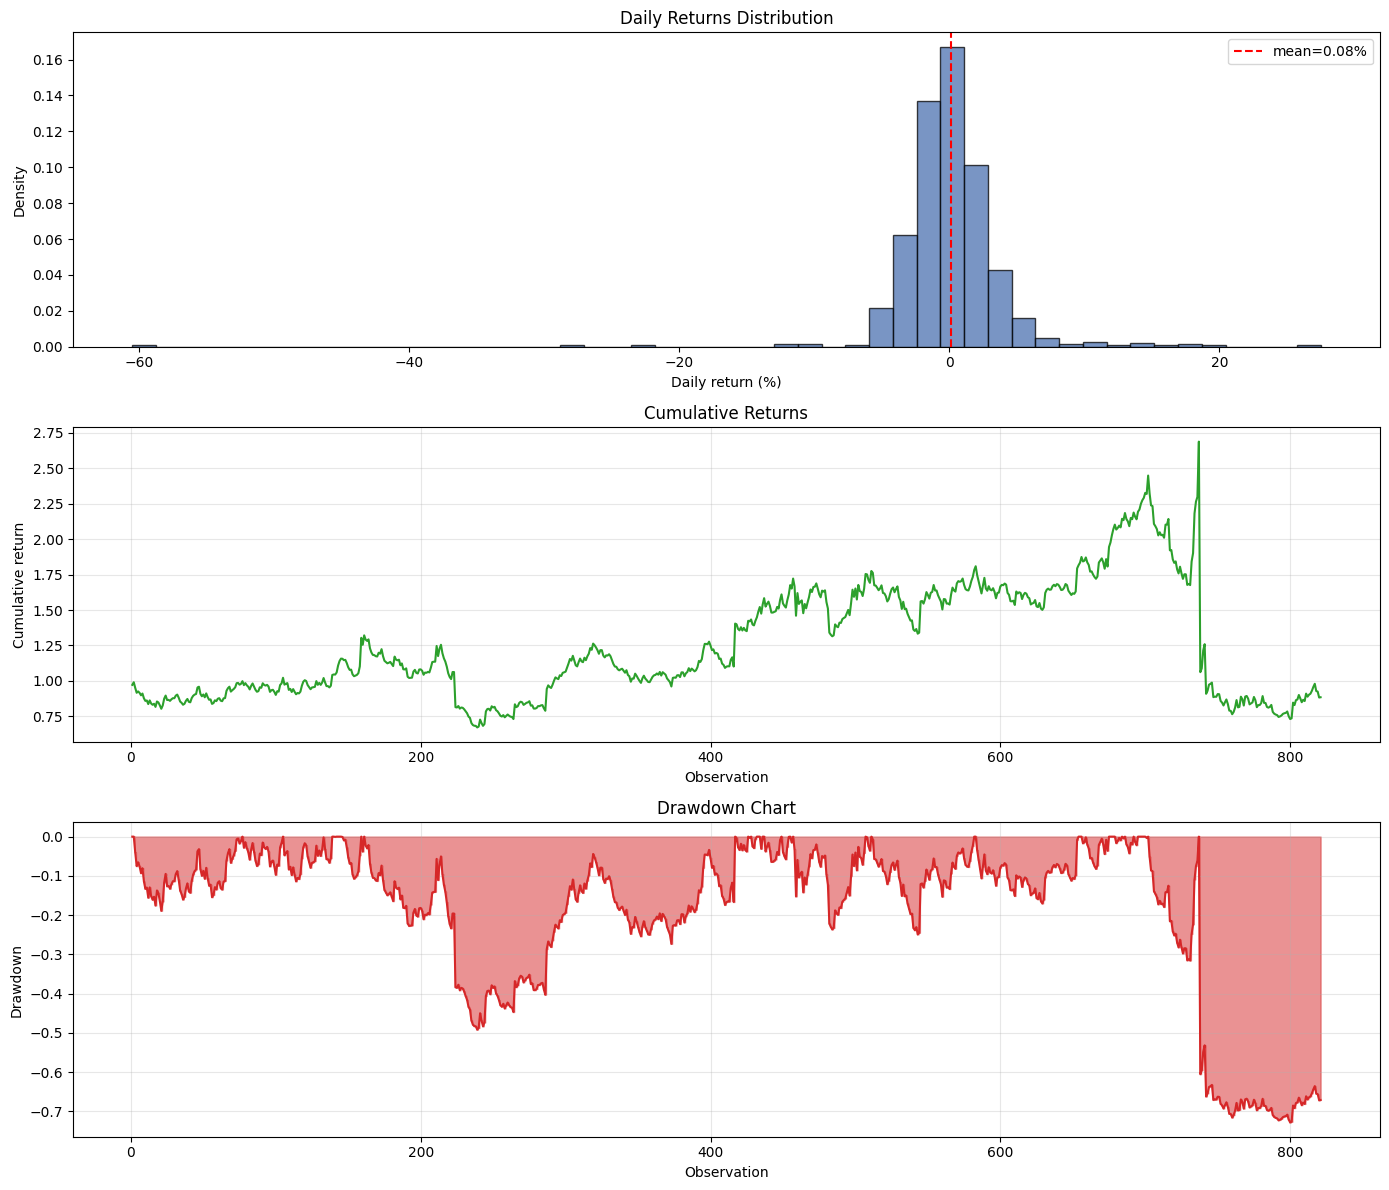

Metrics for natgasmini:
  annual_return: -3.7404 - Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.
  annual_volatility: 65.2239 - Annualized standard deviation of daily returns using 256 trading days.
  sharpe_ratio: 33.3545 - Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.
  max_drawdown: -72.7973 - Largest peak-to-trough decline in cumulative returns during the sample period.
  drawdown_duration: 255.0000 - Maximum number of consecutive days spent below the previous peak.
  skewness: -3.6061 - Measure of asymmetry in the daily return distribution.
  left_tail_mean_5pct: -7.8432 - Average return in the worst 5% of daily observations.
  right_tail_mean_5pct: 9.0579 - Average return in the best 5% of daily observations.
  left_tail_threshold_5pct: -3.9588 - The 5th percentile return, used to define the left tail.
  right_tail_threshold_5pct: 4.9173 - The 95th percentile return, used to de

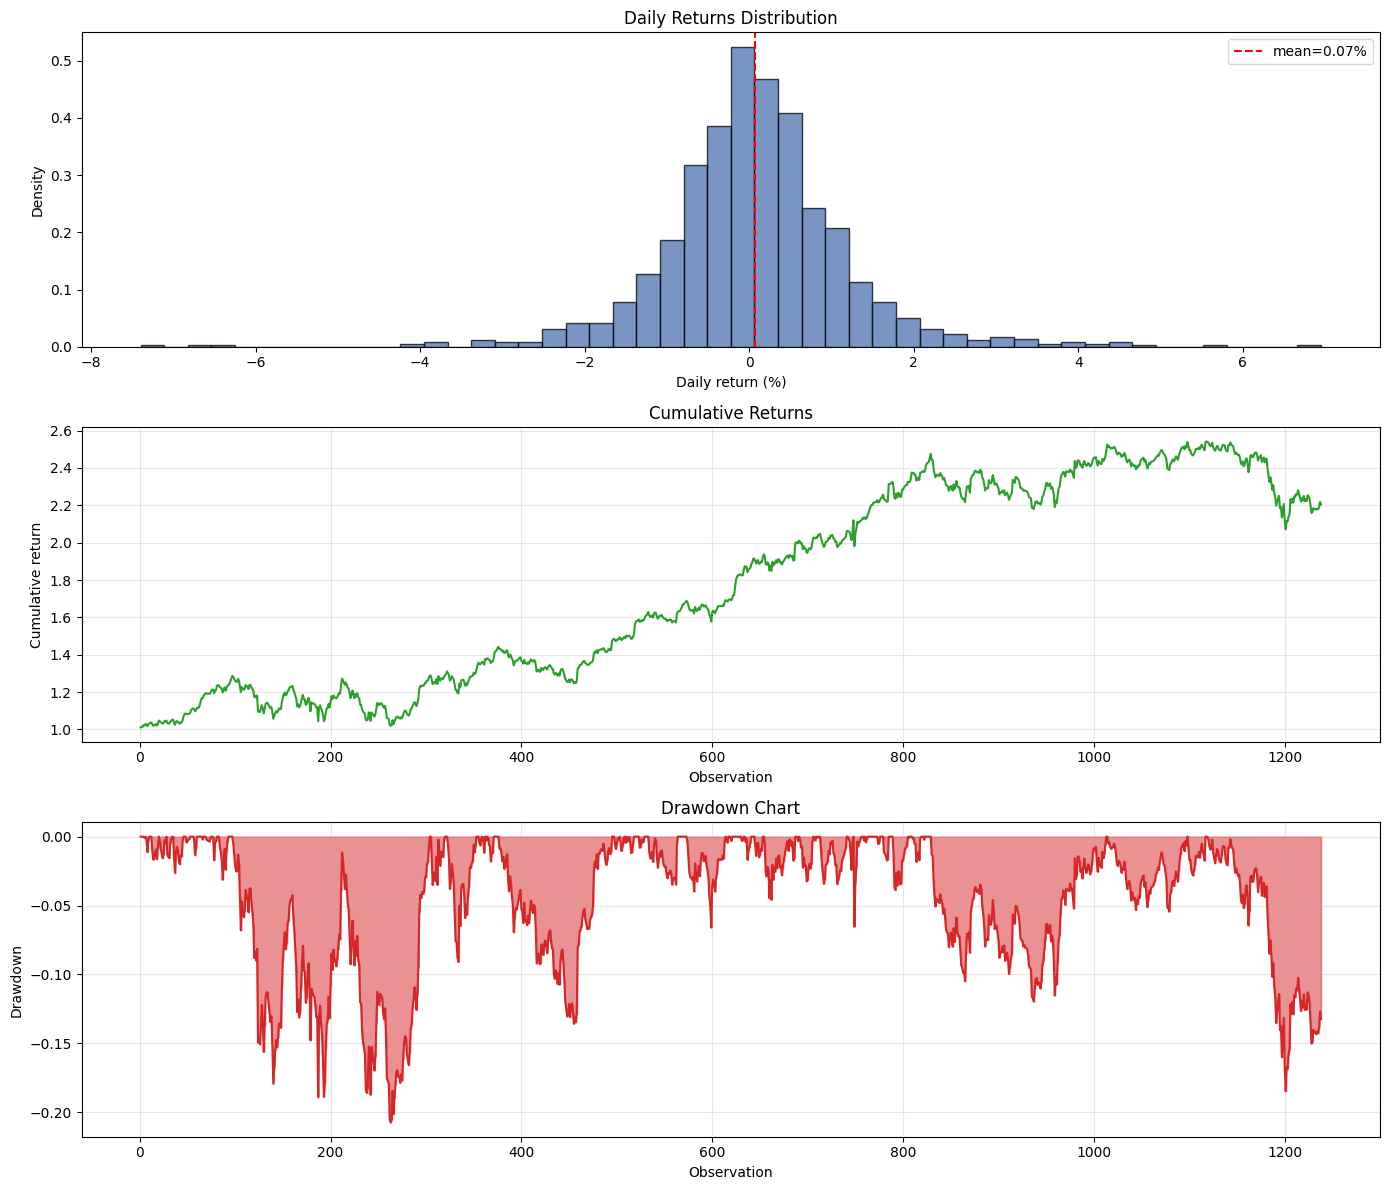

Metrics for nifty:
  annual_return: 17.7602 - Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.
  annual_volatility: 18.4398 - Annualized standard deviation of daily returns using 256 trading days.
  sharpe_ratio: 97.8980 - Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.
  max_drawdown: -20.7337 - Largest peak-to-trough decline in cumulative returns during the sample period.
  drawdown_duration: 206.0000 - Maximum number of consecutive days spent below the previous peak.
  skewness: -0.0322 - Measure of asymmetry in the daily return distribution.
  left_tail_mean_5pct: -2.5725 - Average return in the worst 5% of daily observations.
  right_tail_mean_5pct: 2.8654 - Average return in the best 5% of daily observations.
  left_tail_threshold_5pct: -1.5906 - The 5th percentile return, used to define the left tail.
  right_tail_threshold_5pct: 1.8104 - The 95th percentile return, used to define 

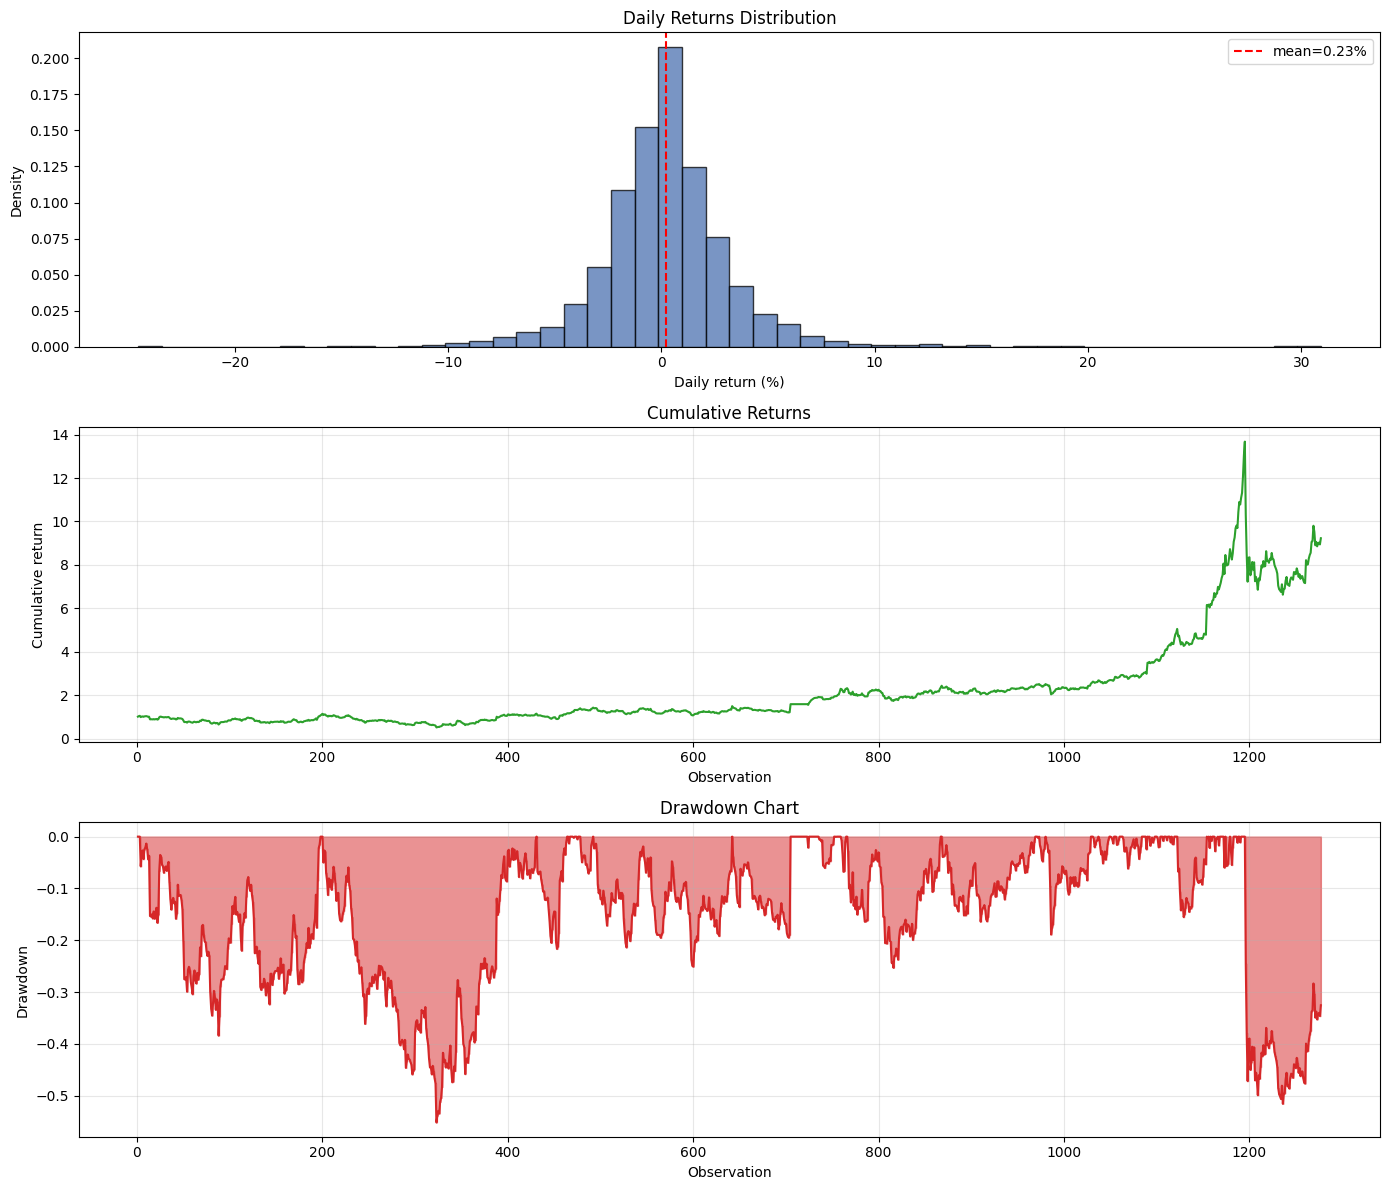

Metrics for silvermic:
  annual_return: 56.1266 - Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.
  annual_volatility: 54.8005 - Annualized standard deviation of daily returns using 256 trading days.
  sharpe_ratio: 108.3091 - Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.
  max_drawdown: -55.1512 - Largest peak-to-trough decline in cumulative returns during the sample period.
  drawdown_duration: 230.0000 - Maximum number of consecutive days spent below the previous peak.
  skewness: 0.9920 - Measure of asymmetry in the daily return distribution.
  left_tail_mean_5pct: -7.3197 - Average return in the worst 5% of daily observations.
  right_tail_mean_5pct: 8.7017 - Average return in the best 5% of daily observations.
  left_tail_threshold_5pct: -4.3825 - The 5th percentile return, used to define the left tail.
  right_tail_threshold_5pct: 5.1927 - The 95th percentile return, used to def

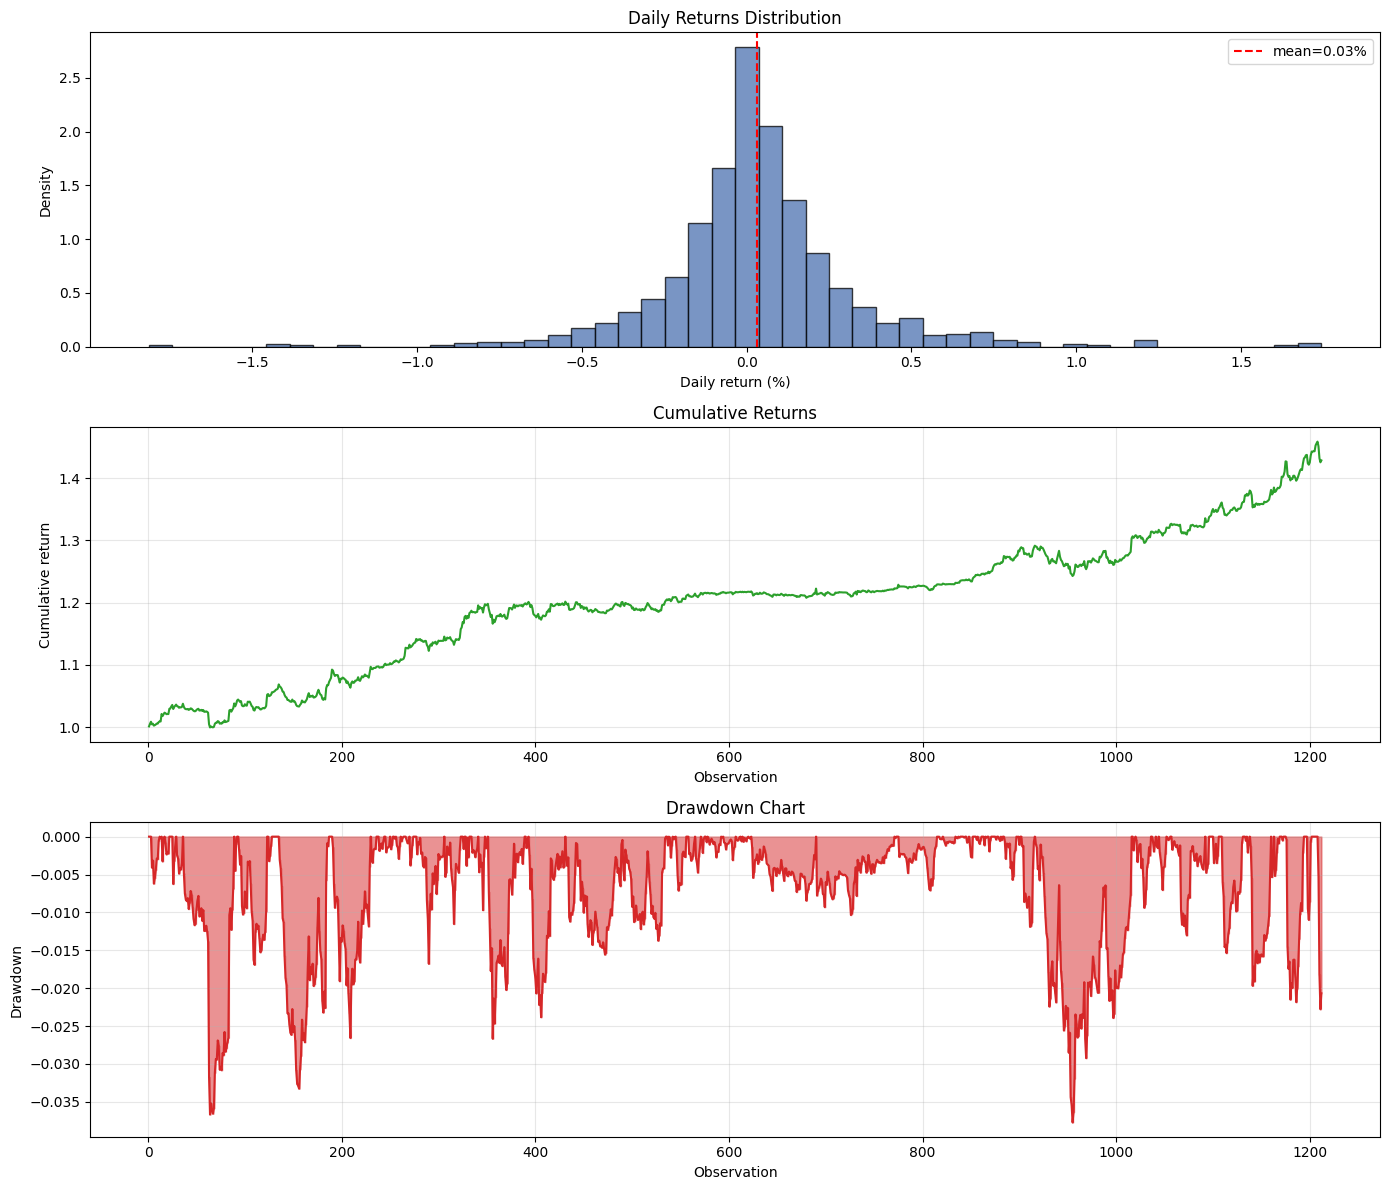

Metrics for usdinr:
  annual_return: 7.8197 - Compound annual growth rate based on the daily adjusted returns and 256 trading days per year.
  annual_volatility: 4.7281 - Annualized standard deviation of daily returns using 256 trading days.
  sharpe_ratio: 161.6237 - Ratio of annualized excess return to annualized volatility. Uses the provided annual risk-free rate.
  max_drawdown: -3.7724 - Largest peak-to-trough decline in cumulative returns during the sample period.
  drawdown_duration: 103.0000 - Maximum number of consecutive days spent below the previous peak.
  skewness: 0.4099 - Measure of asymmetry in the daily return distribution.
  left_tail_mean_5pct: -0.6378 - Average return in the worst 5% of daily observations.
  right_tail_mean_5pct: 0.7848 - Average return in the best 5% of daily observations.
  left_tail_threshold_5pct: -0.4030 - The 5th percentile return, used to define the left tail.
  right_tail_threshold_5pct: 0.4949 - The 95th percentile return, used to define th

In [48]:
for instrument in instruments:
    print(f"Calculating return stats for {instrument}...")
    result = calculate_return_stats(instruments[instrument], price_col='close_adj', date_col='date', rf=0.0, plot=True)
    print(f"Metrics for {instrument}:")
    for metric, value in result['metrics'].items():
        explanation = result['explanations'].get(metric, '')
        print(f"  {metric}: {value:.4f} - {explanation}")
    print("\n")

### Correlation Heatmap

In [53]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_instrument_return_correlation(
    returns_data,
    return_col='returns',
    date_col='date',
    title='Instrument Return Correlation Heatmap',
    figsize=(10, 8),
    cmap='vlag',
    annot=True,
):
    """Calculate return correlations between instruments and plot a heatmap.

    Args:
        returns_data (dict or pd.DataFrame): If a dict, values can be pd.Series of returns or pd.DataFrame containing a returns column. If a DataFrame, each column is assumed to be a return series, and the date column is used as the index.
        return_col (str): column name for returns when values are DataFrames.
        date_col (str): optional date column used to align returns by date.
        title (str): chart title.
        figsize (tuple): figure size.
        cmap (str): heatmap colormap.
        annot (bool): whether to annotate cells with correlation values.

    Returns:
        pd.DataFrame: correlation matrix.
    """

    def normalize_datetime_index(index):
        if not isinstance(index, pd.DatetimeIndex):
            index = pd.to_datetime(index, errors='coerce')
        if index.tz is not None:
            index = index.tz_convert(None)
        return index

    def normalize_series(series):
        series.index = normalize_datetime_index(series.index)
        series = series[~series.index.isna()]
        series = series.sort_index()
        if series.index.duplicated().any():
            series = series[~series.index.duplicated(keep='last')]
        return series

    if isinstance(returns_data, dict):
        series_dict = {}
        seen_names = set()
        for name, value in returns_data.items():
            normalized_name = str(name).strip()
            name_key = normalized_name.lower()
            if name_key in seen_names:
                raise ValueError(f"Duplicate instrument name detected (case-insensitive): {normalized_name}")
            seen_names.add(name_key)

            if isinstance(value, pd.DataFrame):
                if return_col not in value.columns:
                    raise ValueError(f"DataFrame for '{normalized_name}' must contain the '{return_col}' column.")
                if date_col in value.columns:
                    series = value.set_index(date_col)[return_col].copy()
                else:
                    series = value[return_col].copy()
            elif isinstance(value, pd.Series):
                series = value.copy()
            else:
                raise TypeError('Dictionary values must be pandas Series or DataFrame objects.')

            series = normalize_series(series)
            series.name = normalized_name
            if not series.empty:
                series_dict[normalized_name] = series

        if not series_dict:
            raise ValueError('No valid return series found in returns_data.')

        df = pd.concat(series_dict, axis=1)
    elif isinstance(returns_data, pd.DataFrame):
        df = returns_data.copy()
        if date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
            if df[date_col].dt.tz is not None:
                df[date_col] = df[date_col].dt.tz_convert(None)
            df = df.set_index(date_col)
            if df.index.duplicated().any():
                df = df[~df.index.duplicated(keep='last')]
        df = df.sort_index()
    else:
        raise TypeError('returns_data must be a dict or pandas DataFrame.')

    if df.columns.duplicated().any():
        duplicate_cols = df.columns[df.columns.duplicated()].unique().tolist()
        raise ValueError(f'Duplicate correlation series names found: {duplicate_cols}')

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all')

    corr = df.corr()

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr,
        annot=annot,
        fmt='.2f',
        cmap=cmap,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.75,
        linecolor='white',
        annot_kws={'size': 10, 'weight': 'bold'},
        cbar_kws={'shrink': 0.8, 'ticks': [-1, -0.5, 0, 0.5, 1]},
        ax=ax,
    )
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return corr


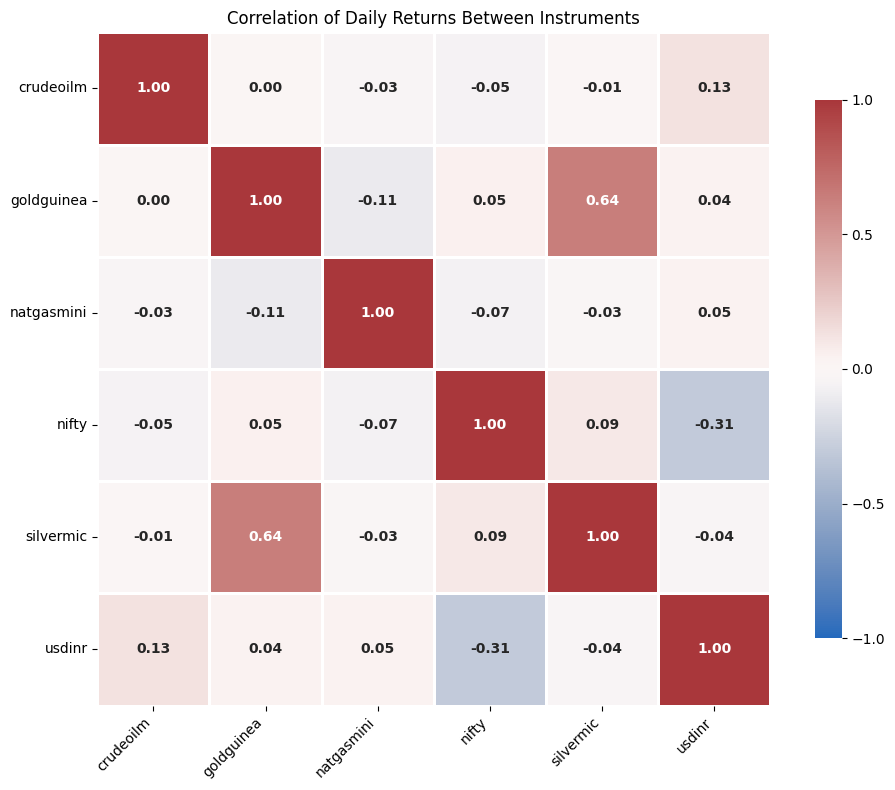

,crudeoilm,goldguinea,natgasmini,nifty,silvermic,usdinr
crudeoilm,1.000000,0.003249,-0.032904,-0.054901,-0.010472,0.125619
goldguinea,0.003249,1.000000,-0.110016,0.051074,0.635312,0.041914
natgasmini,-0.032904,-0.110016,1.000000,-0.067108,-0.030713,0.046058
nifty,-0.054901,0.051074,-0.067108,1.000000,0.094445,-0.310011
silvermic,-0.010472,0.635312,-0.030713,0.094445,1.000000,-0.038043
usdinr,0.125619,0.041914,0.046058,-0.310011,-0.038043,1.000000


In [54]:
for instrument in instruments.keys():
    instruments[instrument] = calculate_returns(instruments[instrument])

plot_instrument_return_correlation(instruments, return_col='returns', title='Correlation of Daily Returns Between Instruments')

In [41]:
instruments['nifty'].head()

,date,close,close_adj,returns
0,2021-05-27,15463.85,10846.50,NaN
1,2021-05-30,15583.20,10965.85,0.011004
2,2021-05-31,15618.15,11000.80,0.003187
3,2021-06-01,15616.75,10999.40,-0.000127
4,2021-06-02,15712.40,11095.05,0.008696
